In [1]:
%run import_libs.py

In [4]:
root = 'D:/yueying/gazeObject_YueyingDong/results/'

# rsa

In [19]:
loadRaw = False
mergeTags = False
loadScanpath = True
correctOnly = False
trlType = ['precue','retrocue']
comparison = 'stim2delay'


In [20]:
"""load trial ordering"""
precuePath1 = glob.glob(root + "variables/scanMatchTrlOrdering/311to352/*.csv")
retrocuePath1 = glob.glob(root + "variables/scanMatchTrlOrdering/360to400/*.csv")

#load trial info
if len(trlType) != 0:
    thisPath = precuePath1 + retrocuePath1
elif trlType == 'precue':
    thisPath = precuePath1
else:
    thisPath = retrocuePath1

#load trl ordering    
trlOrdering = pd.DataFrame()
for i in thisPath:
    trlOrdering = pd.concat([trlOrdering,pd.read_csv(i).iloc[:,2:]]) 

trlOrdering = trlOrdering.reset_index(drop=True)

In [38]:
def loadScanPathRawMat_oneSubj(subjID,comparison = 'stim2delay'):
    
    experiment = '360to400'
    if subjID <= 352:
        experiment = '311to352'

    mat_data = loadmat(glob.glob(f'{root}/scanMatch_similarity/{experiment}_{comparison}/*{str(int(subjID))[:3]}*.mat')[0])
    similarityArr = mat_data['similarityArr']

    # zscore for each subj
    similarityArr = np.where(similarityArr == 9999,np.nan,similarityArr)
    similarityArr = (similarityArr - np.nanmean(similarityArr))/np.nanstd(similarityArr)
    return similarityArr

In [22]:
def loadRSA(loadScanpath,comparison,trlOrdering,normalizationMethod = 'zscore',debug = False):

    """load scan path similarity"""
    if loadScanpath == True:

        trl_withScore_formatted_sp = pd.DataFrame()

        """loop through the scanpath similarity matrix for all subject, extracting relevant information"""
        for subjID in trlOrdering.participant.unique():

            #initialize empty arrays
            withinTrl = []
            acrossTrl_sameImage = []
            acrossTrl_sameImage_vis = []
            acrossTrl_sameImage_ver = []
            acrossTrl_diffImage = []
            acrossTrl_diffImage_vis = []
            acrossTrl_diffImage_ver = []

            if (subjID <= 352) : #precue
                thisFileID = glob.glob(f'{root}/variables/scanMatchTrlID/311to352/*{str(int(subjID))[:3]}*.npy')
            else: #retrocue
                thisFileID = glob.glob(f'{root}/variables/scanMatchTrlID/360to400/*{str(int(subjID))[:3]}*.npy')

            #get the subj ID info, this will be used to check if the trl index are correct
            saccTrlIDs = np.load(thisFileID[0],allow_pickle = True)
            saccTrlIDs = [str((i.split('_')[0][1:],
                            int(i.split('_')[1]),
                            int(i.split('_')[2]))) for i in saccTrlIDs]

            print('handling...',subjID)

            # load the subject's scanmatch matrix
            similarityArr = loadScanPathRawMat_oneSubj(subjID)
            # get the trial info for this subject
            trlInfo_thisSubj = trlOrdering[trlOrdering.participant == subjID].reset_index(drop = True)
            
            #check if the trial is is correct
            if np.array_equal(trlInfo_thisSubj.TRIALID.values, saccTrlIDs):

                visual_mask = (trlInfo_thisSubj.trlType == 'visual')
                verbal_mask = (trlInfo_thisSubj.trlType == 'verbal')

                #for each trial
                for n,i in enumerate(trlInfo_thisSubj.TRIALID.unique()):  
                    #get the indices of other trials with the same image
                    trlThis = trlInfo_thisSubj[trlInfo_thisSubj.TRIALID == i] 
                    image_this_trial = trlThis.stimImage.values[0]

                    
                    trial_mask = (trlInfo_thisSubj.TRIALID != i)
                    image_mask = (trlInfo_thisSubj.stimImage == image_this_trial)

                    
                    #compare current trial, to trials with the same image (the comparison trial is seperated into visual and verbal)
                    sameImageIndices = trlInfo_thisSubj[image_mask & trial_mask].index.values
                    sameImageIndices_vis = trlInfo_thisSubj[image_mask & trial_mask  & visual_mask].index.values
                    sameImageIndices_ver = trlInfo_thisSubj[image_mask & trial_mask  & verbal_mask].index.values

                    
                    #get the indices from other trls
                    diffImageIndices = trlInfo_thisSubj[~image_mask].index.values  
                    diffImageIndices_vis =  trlInfo_thisSubj[~image_mask & visual_mask].index.values
                    diffImageIndices_ver =  trlInfo_thisSubj[~image_mask & verbal_mask].index.values


                    #extract the similarity values using the index
                    withinTrl.append(similarityArr[n,n])
                    acrossTrl_sameImage.append(np.nanmean(similarityArr[n,sameImageIndices]))
                    acrossTrl_sameImage_vis.append(np.nanmean(similarityArr[n,sameImageIndices_vis]))
                    acrossTrl_sameImage_ver.append(np.nanmean(similarityArr[n,sameImageIndices_ver]))

                    acrossTrl_diffImage.append(np.nanmean(similarityArr[n,diffImageIndices]))
                    acrossTrl_diffImage_vis.append(np.nanmean(similarityArr[n,diffImageIndices_vis]))
                    acrossTrl_diffImage_ver.append(np.nanmean(similarityArr[n,diffImageIndices_ver]))


                    
            else:
                raise('the subject trial id from trlInfo_thisSubj does not match saccTrlId')
            
            similarityScores = pd.DataFrame(dict(zip(['within','across trial','diff image',
                                                    'across trial, visTarget','across trial, verTarget',
                                                    'diff image, visTarget','diff image, verTarget',],
                                                    [withinTrl,acrossTrl_sameImage,acrossTrl_diffImage,
                                                    acrossTrl_sameImage_vis, acrossTrl_sameImage_ver,
                                                    acrossTrl_diffImage_vis, acrossTrl_diffImage_ver])))
            if debug:
                print(f'/tab trl_withScore_formatted_sp shape is {trl_withScore_formatted_sp.shape}',
                    f'similarityScores shape is {similarityScores.shape}',
                    f'unique columns are {similarityScores.columns}')
            
            #append the subject to the larger df
            trl_withScore_formatted_sp = pd.concat([trl_withScore_formatted_sp,similarityScores],axis = 0)

        #necessary formatting
        trl_withScore = pd.concat([trlOrdering,trl_withScore_formatted_sp.reset_index(drop = True)],axis = 1)
        trl_withScore['trlOrder'] = [ast.literal_eval(i)[2] * 20 + ast.literal_eval(i)[1] for i in trl_withScore.TRIALID]
        trl_withScore['imageRepeate'] = trl_withScore.sort_values('trlOrder',ascending=True).groupby(['participant','stimImage',]).cumcount()
        trl_withScore['imageRepeate_trlType'] = trl_withScore.sort_values('trlOrder',ascending=True).groupby(['participant','stimImage','trlType']).cumcount()
        
        #make it from wide to long
        trl_withScore_formatted_sp = pd.melt(trl_withScore,  
                                             id_vars=['trlType','participant','TRIALID','stimImage','imageRepeate','imageRepeate_trlType'],
                                                        value_vars=['within', 'across trial', 'diff image',
                                                                    'across trial, visTarget','across trial, verTarget',
                                                                    'diff image, visTarget','diff image, verTarget'],
                                                        var_name='category', value_name=f'similarityScore_{comparison}')
        
        return trl_withScore_formatted_sp
   

In [23]:
#create a plotting function that plots the difference score, for both cue tasks
#that shows visvis - visver and verver - vervis for each trial (base on whether the current trial is vis or ver)
#then take average, generate plot and calculate statistics
def plotConditionalDiff_Score(ax,comparison = 'stim2delay',score = 'similarityScore',meanType = 'subj'):
    
    #transform the trl_withScore_formatted
    loadWhat = f'{score}_{comparison}' 
    acrossTrlTemp = trl_withScore_formatted[trl_withScore_formatted.category !='within']
    acrossTrlDiff = acrossTrlTemp.pivot(index = 'TRIALID',columns = 'category', values=loadWhat).reset_index()

    #calculate the diff score
    #the diffScore_byTargetTrl is for every trial, vis - ver
    #the diffScore_byTargetTrl_signCorrected is, for every trial, use the congruent score (vis-vis, ver-ver) minus the other one
    acrossTrlDiff = acrossTrlDiff.merge(acrossTrlTemp[['TRIALID','participant','trlType','task','imageRepeate','stimImage']].drop_duplicates(),how = 'left')
    acrossTrlDiff['diffScore_byTargetTrl'] = acrossTrlDiff['across, same image, visTarget'] - acrossTrlDiff['across, same image, verTarget']
    acrossTrlDiff['diffScore_byTargetTrl_signCorrected'] = [visScore - verScore if acrossTrlDiff.trlType[n] == 'visual' else verScore - visScore for n,(verScore,visScore) in enumerate(zip(acrossTrlDiff['across, same image, verTarget'],
                                                                                acrossTrlDiff['across, same image, visTarget']))]
    
    #take mean
    if meanType == 'subj':
        print('calculating subject mean')
        acrossTrlDiffMean = acrossTrlDiff.groupby(['task','participant','trlType',]).mean(numeric_only=True).reset_index()
    else:
        acrossTrlDiffMean = acrossTrlDiff
    

    #fig,ax = plt.subplots(ncols = len(categoryOrder4Plotting), figsize = (20,10),sharex=True,sharey=True)

    
    f = sns.barplot(x = 'task',hue = 'trlType', order = ['precue','retrocue'],hue_order = ['visual','verbal'],
                palette=['green','purple',], y = 'diffScore_byTargetTrl_signCorrected',data = acrossTrlDiffMean,alpha = 0.5,ax = ax)


    
    
    ax.set_xlabel('condition',fontsize = 15)
    ax.set_title(f'mean {score} score \n congruent comparison - incongruent, {comparison}',y = 1,fontsize = 10)
   
    return acrossTrlDiffMean


# Supplementary Figure 1A

In [39]:
#initialize empty arrays
withinTrl = []
acrossTrl_sameImage = []
acrossTrl_sameImage_vis = []
acrossTrl_sameImage_ver = []
acrossTrl_diffImage = []

# to test the effect of batch size on different images, requested by reviewer 2
different_image_median = []
different_image_mean = []
n_levels_diff_image_batch_size = 10
min_diff_image_batch_size = 10

median_arr_all_subj = np.empty(
        (
            41,
            n_levels_diff_image_batch_size
        )
)
mean_arr_all_subj = np.empty(
    (
        41,
        n_levels_diff_image_batch_size
    )
)

image_specificity_median_all_subj = np.empty(
    (
        41,
        n_levels_diff_image_batch_size
    )
)

image_specificity_mean_all_subj = np.empty(
    (
        41,
        n_levels_diff_image_batch_size
    )
)

across_same_image_median_all_subj = np.empty(41)
across_same_image_mean_all_subj = np.empty(41)
withinTrl_all_subj = np.empty(41)



for cnt,subjID in enumerate(trlOrdering.participant.unique()[:41].astype(int)):

    #initialize empty arrays
    withinTrl = []
    acrossTrl_sameImage_median = []
    acrossTrl_sameImage_mean = []

    # to test the effect of batch size on different images, requested by reviewer 2
    different_image_median = []
    different_image_mean = []

    # get the image specificity evals: across trial - diff image
    image_specificity_median = []
    image_specificity_mean = []


    thisFileID = glob.glob(f'D:/yueying/gazeObject_YueyingDong/results/variables/scanMatchTrlID/311to352/*{str(int(subjID))[:3]}*.npy')
    saccTrlIDs = np.load(thisFileID[0],allow_pickle = True)
    saccTrlIDs = [str((i.split('_')[0][1:],int(i.split('_')[1]),int(i.split('_')[2]))) for i in saccTrlIDs]
    trlInfo_thisSubj = trlOrdering[trlOrdering['TRIALID'].isin((saccTrlIDs))].reset_index(drop = True)
    similarityArr = loadScanPathRawMat_oneSubj(subjID,'stim2delay')

        
    #check if the trial is is correct
    if sum(trlInfo_thisSubj.TRIALID != saccTrlIDs) == 0:

        #for each trial
        for n,i in enumerate(trlInfo_thisSubj.TRIALID.unique()):
        
            #get the indices of other trials with the same image
            trlThis = trlInfo_thisSubj[trlInfo_thisSubj.TRIALID == i] 
            sameImageTrls = trlInfo_thisSubj[(trlInfo_thisSubj.stimImage == trlThis.stimImage.values[0]) &
                                            (trlInfo_thisSubj.TRIALID != i)]
            sameImageIndices = sameImageTrls.index.values

            #get the indices from other trls
            diffImageTrls = trlInfo_thisSubj[(trlInfo_thisSubj.stimImage != trlThis.stimImage.values[0])]
            diffImageIndices = diffImageTrls.index.values

            q = []
            j = []
            for this_batch_size in np.linspace(min_diff_image_batch_size,
                                                311, 
                                                n_levels_diff_image_batch_size).astype(int):
                
                this_batch_indicies = np.random.choice(diffImageIndices,size=this_batch_size, replace=True)
                
                q.append(
                    np.nanmedian(similarityArr[n,this_batch_indicies])
                ) 
                j.append(
                    np.nanmean(similarityArr[n,this_batch_indicies])
                    )
                
            withinTrl.append(similarityArr[n,n])

            acrossTrl_median_value = np.nanmedian(similarityArr[n,sameImageIndices])
            acrossTrl_mean_value = np.nanmean(similarityArr[n,sameImageIndices])
            acrossTrl_sameImage_median.append(acrossTrl_median_value)
            acrossTrl_sameImage_mean.append(acrossTrl_mean_value)

            different_image_median.append(q)                
            different_image_mean.append(j)

            # append the image specificity values, which is the difference between same image 
            # and different image (for all of the sample size bin)
            image_specificity_median.append(
                np.subtract(acrossTrl_median_value,q)
            )
            image_specificity_mean.append(
                np.subtract(acrossTrl_mean_value,j)
            )

    
    median_arr_all_subj[cnt] = np.nanmean(np.array(different_image_median),axis = 0)  
    mean_arr_all_subj[cnt] = np.nanmean(np.array(different_image_mean),axis = 0)
    across_same_image_median_all_subj[cnt] = np.nanmean(acrossTrl_sameImage_median)
    across_same_image_mean_all_subj[cnt] = np.nanmean(acrossTrl_sameImage_mean)
    withinTrl_all_subj[cnt] = np.nanmean(withinTrl)

    image_specificity_median_all_subj[cnt] = np.nanmean(np.array(image_specificity_median),axis = 0)
    image_specificity_mean_all_subj[cnt] = np.nanmean(np.array(image_specificity_mean),axis = 0)

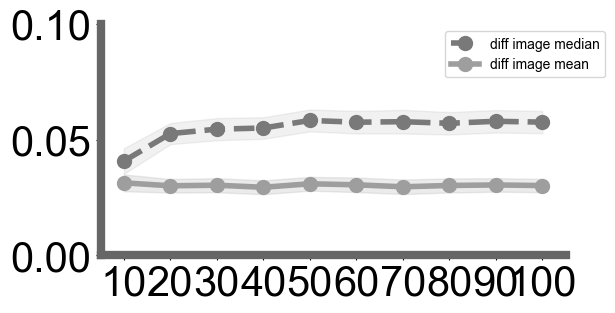

In [41]:
fs(5,5)
x = np.linspace(10,100,10)

#plot diff image median
subj_mean = np.nanmean(image_specificity_median_all_subj,axis = 0)
subj_sderr = stats.sem(image_specificity_median_all_subj, axis=0, nan_policy='omit')

fig,ax = plt.subplots(figsize = (6,3))

ax.plot(x, subj_mean,
         label = 'diff image median',
         linewidth = 4, linestyle = 'dashed',
         marker = 'o',
         markersize=10,
         c = '#797979ff')
ax.fill_between(x,
                 subj_mean + subj_sderr, 
                 subj_mean - subj_sderr,
                 alpha = 0.1,color = '#797979ff')

#plot diff image mean
subj_mean_mean = np.nanmean(image_specificity_mean_all_subj,axis = 0)
subj_mean_sderr = stats.sem(image_specificity_mean_all_subj, axis=0, nan_policy='omit')

ax.plot(x, subj_mean_mean,
         label = 'diff image mean',
         linewidth = 4, linestyle = '-',
         markersize=10,
         marker = 'o',
         c = '#9e9e9eff')
ax.fill_between(x,
                subj_mean_mean + subj_mean_sderr, 
                subj_mean_mean - subj_mean_sderr,
                alpha = 0.2,color = '#9e9e9eff')

plt.ylim(0,0.1)
plt.legend(bbox_to_anchor = [1.1,1])
plt.xlim(5,105)
plt.tick_params(labelsize=30)


ax = plt.gca()
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
for spine_name, spine in ax.spines.items():
        if spine_name in ['top', 'right']:
                spine.set_visible(False)
        else:
                spine.set_linewidth(6)
                spine.set_color('#666666')

In [42]:
#initialize empty arrays
withinTrl = []
acrossTrl_sameImage = []
acrossTrl_sameImage_vis = []
acrossTrl_sameImage_ver = []
acrossTrl_diffImage = []

# to test the effect of batch size on different images, requested by reviewer 2
different_image_median = []
different_image_mean = []
n_levels_diff_image_batch_size = 10
min_diff_image_batch_size = 10

median_arr_all_subj = np.empty(
        (
            41,
            n_levels_diff_image_batch_size
        )
)
mean_arr_all_subj = np.empty(
    (
        41,
        n_levels_diff_image_batch_size
    )
)

image_specificity_median_all_subj = np.empty(
    (
        41,
        n_levels_diff_image_batch_size
    )
)

image_specificity_mean_all_subj = np.empty(
    (
        41,
        n_levels_diff_image_batch_size
    )
)

across_same_image_median_all_subj = np.empty(41)
across_same_image_mean_all_subj = np.empty(41)
withinTrl_all_subj = np.empty(41)



for cnt,subjID in enumerate(trlOrdering.participant.unique()[41:].astype(int)):

    #initialize empty arrays
    withinTrl = []
    acrossTrl_sameImage_median = []
    acrossTrl_sameImage_mean = []

    # to test the effect of batch size on different images, requested by reviewer 2
    different_image_median = []
    different_image_mean = []

    # get the image specificity evals: across trial - diff image
    image_specificity_median = []
    image_specificity_mean = []


    thisFileID = glob.glob(f'D:/yueying/gazeObject_YueyingDong/results/variables/scanMatchTrlID/360to400/*{str(int(subjID))[:3]}*.npy')
    saccTrlIDs = np.load(thisFileID[0],allow_pickle = True)
    saccTrlIDs = [str((i.split('_')[0][1:],int(i.split('_')[1]),int(i.split('_')[2]))) for i in saccTrlIDs]
    trlInfo_thisSubj = trlOrdering[trlOrdering['TRIALID'].isin((saccTrlIDs))].reset_index(drop = True)
    similarityArr = loadScanPathRawMat_oneSubj(subjID,'stim2delay')

        
    #check if the trial is is correct
    if sum(trlInfo_thisSubj.TRIALID != saccTrlIDs) == 0:

        #for each trial
        for n,i in enumerate(trlInfo_thisSubj.TRIALID.unique()):
        
            #get the indices of other trials with the same image
            trlThis = trlInfo_thisSubj[trlInfo_thisSubj.TRIALID == i] 
            sameImageTrls = trlInfo_thisSubj[(trlInfo_thisSubj.stimImage == trlThis.stimImage.values[0]) &
                                            (trlInfo_thisSubj.TRIALID != i)]
            sameImageIndices = sameImageTrls.index.values

            #get the indices from other trls
            diffImageTrls = trlInfo_thisSubj[(trlInfo_thisSubj.stimImage != trlThis.stimImage.values[0])]
            diffImageIndices = diffImageTrls.index.values

            q = []
            j = []
            for this_batch_size in np.linspace(min_diff_image_batch_size,
                                                311,
                                                n_levels_diff_image_batch_size).astype(int):
                
                this_batch_indicies = np.random.choice(diffImageIndices,size=this_batch_size, replace=True)
                
                q.append(
                    np.nanmedian(similarityArr[n,this_batch_indicies])
                ) 
                j.append(
                    np.nanmean(similarityArr[n,this_batch_indicies])
                    )
                
            withinTrl.append(similarityArr[n,n])

            acrossTrl_median_value = np.nanmedian(similarityArr[n,sameImageIndices])
            acrossTrl_mean_value = np.nanmean(similarityArr[n,sameImageIndices])
            acrossTrl_sameImage_median.append(acrossTrl_median_value)
            acrossTrl_sameImage_mean.append(acrossTrl_mean_value)

            different_image_median.append(q)                
            different_image_mean.append(j)

            # append the image specificity values, which is the difference between same image 
            # and different image (for all of the sample size bin)
            image_specificity_median.append(
                np.subtract(acrossTrl_median_value,q)
            )
            image_specificity_mean.append(
                np.subtract(acrossTrl_mean_value,j)
            )

    
    median_arr_all_subj[cnt] = np.nanmean(np.array(different_image_median),axis = 0)  
    mean_arr_all_subj[cnt] = np.nanmean(np.array(different_image_mean),axis = 0)
    across_same_image_median_all_subj[cnt] = np.nanmean(acrossTrl_sameImage_median)
    across_same_image_mean_all_subj[cnt] = np.nanmean(acrossTrl_sameImage_mean)
    withinTrl_all_subj[cnt] = np.nanmean(withinTrl)

    image_specificity_median_all_subj[cnt] = np.nanmean(np.array(image_specificity_median),axis = 0)
    image_specificity_mean_all_subj[cnt] = np.nanmean(np.array(image_specificity_mean),axis = 0)

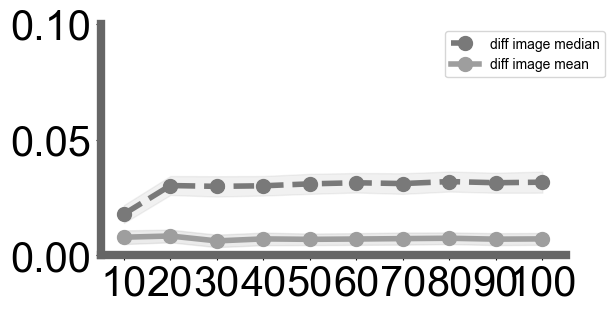

In [43]:
fs(5,5)
x = np.linspace(10,100,10)

#plot diff image median
subj_mean = np.nanmean(image_specificity_median_all_subj,axis = 0)
subj_sderr = stats.sem(image_specificity_median_all_subj, axis=0, nan_policy='omit')

fig,ax = plt.subplots(figsize = (6,3))

ax.plot(x, subj_mean,
         label = 'diff image median',
         linewidth = 4, linestyle = 'dashed',
         marker = 'o',
         markersize=10,
         c = '#797979ff')
ax.fill_between(x,
                 subj_mean + subj_sderr, 
                 subj_mean - subj_sderr,
                 alpha = 0.1,color = '#797979ff')

#plot diff image mean
subj_mean_mean = np.nanmean(image_specificity_mean_all_subj,axis = 0)
subj_mean_sderr = stats.sem(image_specificity_mean_all_subj, axis=0, nan_policy='omit')

ax.plot(x, subj_mean_mean,
         label = 'diff image mean',
         linewidth = 4, linestyle = '-',
         markersize=10,
         marker = 'o',
         c = '#9e9e9eff')
ax.fill_between(x,
                subj_mean_mean + subj_mean_sderr, 
                subj_mean_mean - subj_mean_sderr,
                alpha = 0.2,color = '#9e9e9eff')

plt.ylim(0,0.1)
plt.legend(bbox_to_anchor = [1.1,1])
plt.xlim(5,105)
plt.tick_params(labelsize=30)


ax = plt.gca()
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
for spine_name, spine in ax.spines.items():
        if spine_name in ['top', 'right']:
                spine.set_visible(False)
        else:
                spine.set_linewidth(6)
                spine.set_color('#666666')

In [60]:

# to test the effect of batch size on different images, requested by reviewer 2
different_image_median = []
different_image_mean = []
diff_image_batch_size = 7
n_repeats = 100

median_arr_all_subj = np.empty(
        (
            41,
            n_repeats
        )
)
mean_arr_all_subj = np.empty(
    (
        41,
        n_repeats
    )
)

image_specificity_median_all_subj = np.empty(
    (
        41,
        n_repeats
    )
)

image_specificity_mean_all_subj = np.empty(
    (
        41,
        n_repeats
    )
)


across_same_image_median_all_subj = np.empty(41)
across_same_image_mean_all_subj = np.empty(41)
withinTrl_all_subj = np.empty(41)

for cnt,subjID in enumerate(trlOrdering.participant.unique()[:41].astype(int)):
    print(cnt)
    #initialize empty arrays
    withinTrl = []
    acrossTrl_sameImage_median = []
    acrossTrl_sameImage_mean = []

    # to test the effect of batch size on different images, requested by reviewer 2
    different_image_median = []
    different_image_mean = []

    image_specificity_median = []
    image_specificity_mean = []

    thisFileID = glob.glob(f'D:/yueying/gazeObject_YueyingDong/results/variables/scanMatchTrlID/311to352/*{str(int(subjID))[:3]}*.npy')
    saccTrlIDs = np.load(thisFileID[0],allow_pickle = True)
    saccTrlIDs = [str((i.split('_')[0][1:],int(i.split('_')[1]),int(i.split('_')[2]))) for i in saccTrlIDs]
    trlInfo_thisSubj = trlOrdering[trlOrdering['TRIALID'].isin((saccTrlIDs))].reset_index(drop = True)
    similarityArr = loadScanPathRawMat_oneSubj(subjID,'stim2delay')

        
    #check if the trial is correct
    if sum(trlInfo_thisSubj.TRIALID != saccTrlIDs) == 0:

        #for each trial
        for n,i in enumerate(trlInfo_thisSubj.TRIALID.unique()):
        
            #get the indices of other trials with the same image
            trlThis = trlInfo_thisSubj[trlInfo_thisSubj.TRIALID == i] 
            sameImageTrls = trlInfo_thisSubj[(trlInfo_thisSubj.stimImage == trlThis.stimImage.values[0]) &
                                            (trlInfo_thisSubj.TRIALID != i)]
            sameImageIndices = sameImageTrls.index.values

            #get the indices from other trls
            diffImageTrls = trlInfo_thisSubj[(trlInfo_thisSubj.stimImage != trlThis.stimImage.values[0])]
            diffImageIndices = diffImageTrls.index.values

            q = []
            j = []

            
            for repeat in np.arange(n_repeats):
                this_batch_indicies = np.random.choice(diffImageIndices,
                                                       size=diff_image_batch_size, 
                                                       replace=False)
                
                q.append(
                    np.nanmedian(similarityArr[n,this_batch_indicies])
                ) 
                j.append(
                    np.nanmean(similarityArr[n,this_batch_indicies])
                    )
            
            withinTrl.append(similarityArr[n,n])

            same_image_median_value = np.nanmedian(similarityArr[n,sameImageIndices])
            same_image_mean_value = np.nanmean(similarityArr[n,sameImageIndices])
            acrossTrl_sameImage_median.append(same_image_median_value)
            acrossTrl_sameImage_mean.append(same_image_mean_value)

            different_image_median.append(q)                
            different_image_mean.append(j)

            image_specificity_median.append(
                np.subtract(same_image_median_value,q)
            )
            image_specificity_mean.append(
                np.subtract(same_image_mean_value,j)
            )
    
    withinTrl_all_subj[cnt] = np.nanmean(withinTrl)
    
    across_same_image_median_all_subj[cnt] = np.nanmean(acrossTrl_sameImage_median)
    across_same_image_mean_all_subj[cnt] = np.nanmean(acrossTrl_sameImage_mean)
    
    median_arr_all_subj[cnt] = np.nanmean(np.array(different_image_median),axis = 0)  
    mean_arr_all_subj[cnt] = np.nanmean(np.array(different_image_mean),axis = 0)

    image_specificity_median_all_subj[cnt] = np.nanmean(np.array(image_specificity_median),axis = 0)
    image_specificity_mean_all_subj[cnt] = np.nanmean(np.array(image_specificity_mean),axis = 0)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40


In [61]:
subj_mean = np.nanmean(median_arr_all_subj,axis = 1)
median_all_subj_df_precue = pd.DataFrame(subj_mean,columns=['diff_image_median'])
median_all_subj_df_precue['participant'] = trlOrdering.participant.unique()[41:].astype(int)
median_all_subj_df_precue['across_trial_mean'] = across_same_image_mean_all_subj
median_all_subj_df_precue['across_trial_median'] = across_same_image_median_all_subj

median_all_subj_df_precue['within_trial'] = withinTrl_all_subj
median_all_subj_df_precue['diff_image_mean'] = np.nanmean(mean_arr_all_subj,axis = 1)


median_all_subj_df_precue_long = median_all_subj_df_precue.melt(
    id_vars='participant',
    value_vars = ['diff_image_median',
                  'across_trial_median',
                  'diff_image_mean',
                  'across_trial_mean',
                  'within_trial'],
    value_name='scanpath_similarity',
    var_name= 'comparison'
)

In [62]:
def paired_ttest(df, stat, condition_col='comparison', value_col='scanpath_similarity'):
    diff_image = df[df[condition_col] == f'diff_image_{stat}'][value_col]
    across_trial = df[df[condition_col] == f'across_trial_{stat}'][value_col]
    return stats.ttest_rel(diff_image, across_trial, nan_policy='omit')

paired_ttest(median_all_subj_df_precue_long, 'mean'), paired_ttest(median_all_subj_df_precue_long, 'median')


(TtestResult(statistic=-9.94878677352024, pvalue=2.2390722903377265e-12, df=40),
 TtestResult(statistic=-8.455821047459011, pvalue=1.9261869325946548e-10, df=40))

In [63]:
image_specificity_median_df = pd.DataFrame({
    'participant': trlOrdering.participant.unique()[41:].astype(int),
    'variable':['median']*41,
     'value':image_specificity_median_all_subj.mean(axis = 1)
})

image_specificity_mean_df = pd.DataFrame({
    'participant': trlOrdering.participant.unique()[41:].astype(int),
    'variable':['mean']*41,
     'value':image_specificity_mean_all_subj.mean(axis = 1)
})

image_specificity_df = pd.concat([image_specificity_median_df,image_specificity_mean_df],axis = 0)

(-0.05, 0.15)

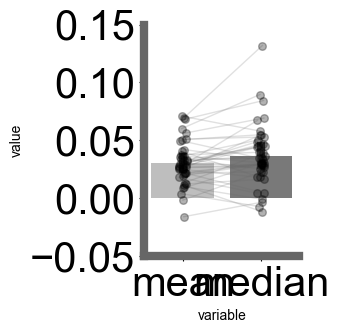

In [64]:
fs(2,3)
subj_col = 'participant'   

f = sns.barplot(x = 'variable', y = 'value',
            hue = 'variable',palette = ["#bebebeff",'#797979ff'],
            order = ['mean','median'],
            hue_order = ['mean','median'],
            errwidth= 6,
            data = image_specificity_df
            )

    
# pivot to one row per subject, one column per condition
wide_df = image_specificity_df[
    image_specificity_df.variable.isin(['mean', 'median'])
].pivot(index=subj_col, columns='variable', values='value')

# small consistent per-subject jitter so points/lines don't all overlap
rng = np.random.default_rng(0)
jitter = rng.uniform(-0.05, 0.05, size=len(wide_df))

for (subj, row), j in zip(wide_df.iterrows(), jitter):
    x0, x1 = 0 + j, 1 + j
    y0, y1 = row['mean'], row['median']
    plt.plot([x0, x1], [y0, y1], color='#666666', alpha=0.2, linewidth=1, zorder=1)
    plt.scatter([x0, x1], [y0, y1], color='black', alpha=0.3, s=30, zorder=3)

f.tick_params(labelsize=30)
for spine_name, spine in f.spines.items():
        if spine_name in ['top', 'right']:
                spine.set_visible(False)
        else:
                spine.set_linewidth(6)
                spine.set_color('#666666')

plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(0.05))
plt.tick_params(labelsize=30)
plt.ylim(-0.05,0.15)


In [65]:
stats.ttest_rel(image_specificity_df[image_specificity_df.variable == 'mean'].value,
                image_specificity_df[image_specificity_df.variable == 'median'].value)

TtestResult(statistic=-2.357254346429915, pvalue=0.023391938395135054, df=40)

In [50]:
#initialize empty arrays
withinTrl = []
acrossTrl_sameImage = []
acrossTrl_sameImage_vis = []
acrossTrl_sameImage_ver = []
acrossTrl_diffImage = []

# to test the effect of batch size on different images, requested by reviewer 2
different_image_median = []
different_image_mean = []
diff_image_batch_size = 7
n_repeats = 100

median_arr_all_subj = np.empty(
        (
            41,
            n_repeats
        )
)
mean_arr_all_subj = np.empty(
    (
        41,
        n_repeats
    )
)

image_specificity_median_all_subj = np.empty(
    (
        41,
        n_repeats
    )
)

image_specificity_mean_all_subj = np.empty(
    (
        41,
        n_repeats
    )
)


across_same_image_median_all_subj = np.empty(41)
across_same_image_mean_all_subj = np.empty(41)
withinTrl_all_subj = np.empty(41)

for cnt,subjID in enumerate(trlOrdering.participant.unique()[41:].astype(int)):
    print(cnt)
    #initialize empty arrays
    withinTrl = []
    acrossTrl_sameImage_median = []
    acrossTrl_sameImage_mean = []

    # to test the effect of batch size on different images, requested by reviewer 2
    different_image_median = []
    different_image_mean = []

    image_specificity_median = []
    image_specificity_mean = []

    thisFileID = glob.glob(f'D:/yueying/gazeObject_YueyingDong/results/variables/scanMatchTrlID/360to400/*{str(int(subjID))[:3]}*.npy')
    saccTrlIDs = np.load(thisFileID[0],allow_pickle = True)
    saccTrlIDs = [str((i.split('_')[0][1:],int(i.split('_')[1]),int(i.split('_')[2]))) for i in saccTrlIDs]
    trlInfo_thisSubj = trlOrdering[trlOrdering['TRIALID'].isin((saccTrlIDs))].reset_index(drop = True)
    similarityArr = loadScanPathRawMat_oneSubj(subjID,'stim2delay')

        
    #check if the trial is correct
    if sum(trlInfo_thisSubj.TRIALID != saccTrlIDs) == 0:

        #for each trial
        for n,i in enumerate(trlInfo_thisSubj.TRIALID.unique()):
        
            #get the indices of other trials with the same image
            trlThis = trlInfo_thisSubj[trlInfo_thisSubj.TRIALID == i] 
            sameImageTrls = trlInfo_thisSubj[(trlInfo_thisSubj.stimImage == trlThis.stimImage.values[0]) &
                                            (trlInfo_thisSubj.TRIALID != i)]
            sameImageIndices = sameImageTrls.index.values

            #get the indices from other trls
            diffImageTrls = trlInfo_thisSubj[(trlInfo_thisSubj.stimImage != trlThis.stimImage.values[0])]
            diffImageIndices = diffImageTrls.index.values

            q = []
            j = []

            
            for repeat in np.arange(n_repeats):
                this_batch_indicies = np.random.choice(diffImageIndices,
                                                       size=diff_image_batch_size, 
                                                       replace=False)
                
                q.append(
                    np.nanmedian(similarityArr[n,this_batch_indicies])
                ) 
                j.append(
                    np.nanmean(similarityArr[n,this_batch_indicies])
                    )
            
            withinTrl.append(similarityArr[n,n])

            same_image_median_value = np.nanmedian(similarityArr[n,sameImageIndices])
            same_image_mean_value = np.nanmean(similarityArr[n,sameImageIndices])
            acrossTrl_sameImage_median.append(same_image_median_value)
            acrossTrl_sameImage_mean.append(same_image_mean_value)

            different_image_median.append(q)                
            different_image_mean.append(j)

            image_specificity_median.append(
                np.subtract(same_image_median_value,q)
            )
            image_specificity_mean.append(
                np.subtract(same_image_mean_value,j)
            )
    
    withinTrl_all_subj[cnt] = np.nanmean(withinTrl)
    
    across_same_image_median_all_subj[cnt] = np.nanmean(acrossTrl_sameImage_median)
    across_same_image_mean_all_subj[cnt] = np.nanmean(acrossTrl_sameImage_mean)
    
    median_arr_all_subj[cnt] = np.nanmean(np.array(different_image_median),axis = 0)  
    mean_arr_all_subj[cnt] = np.nanmean(np.array(different_image_mean),axis = 0)

    image_specificity_median_all_subj[cnt] = np.nanmean(np.array(image_specificity_median),axis = 0)
    image_specificity_mean_all_subj[cnt] = np.nanmean(np.array(image_specificity_mean),axis = 0)

0


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40


In [55]:
subj_mean = np.nanmean(median_arr_all_subj,axis = 1)
median_all_subj_df_retrocue = pd.DataFrame(subj_mean,columns=['diff_image_median'])
median_all_subj_df_retrocue['participant'] = trlOrdering.participant.unique()[41:].astype(int)
median_all_subj_df_retrocue['across_trial_mean'] = across_same_image_mean_all_subj
median_all_subj_df_retrocue['across_trial_median'] = across_same_image_median_all_subj

median_all_subj_df_retrocue['within_trial'] = withinTrl_all_subj
median_all_subj_df_retrocue['diff_image_mean'] = np.nanmean(mean_arr_all_subj,axis = 1)


median_all_subj_df_retrocue_long = median_all_subj_df_retrocue.melt(
    id_vars='participant',
    value_vars = ['diff_image_median',
                  'across_trial_median',
                  'diff_image_mean',
                  'across_trial_mean',
                  'within_trial'],
    value_name='scanpath_similarity',
    var_name= 'comparison'
)

In [56]:
def paired_ttest(df, stat, condition_col='comparison', value_col='scanpath_similarity'):
    diff_image = df[df[condition_col] == f'diff_image_{stat}'][value_col]
    across_trial = df[df[condition_col] == f'across_trial_{stat}'][value_col]
    return stats.ttest_rel(diff_image, across_trial, nan_policy='omit')

paired_ttest(median_all_subj_df_retrocue_long, 'mean'), paired_ttest(median_all_subj_df_retrocue_long, 'median')


(TtestResult(statistic=-2.9295065867302803, pvalue=0.005583760381736617, df=40),
 TtestResult(statistic=-3.6447943819624085, pvalue=0.0007619895974236121, df=40))

In [57]:
image_specificity_median_df = pd.DataFrame({
    'participant': trlOrdering.participant.unique()[41:].astype(int),
    'variable':['median']*41,
     'value':image_specificity_median_all_subj.mean(axis = 1)
})

image_specificity_mean_df = pd.DataFrame({
    'participant': trlOrdering.participant.unique()[41:].astype(int),
    'variable':['mean']*41,
     'value':image_specificity_mean_all_subj.mean(axis = 1)
})

image_specificity_df = pd.concat([image_specificity_median_df,image_specificity_mean_df],axis = 0)

(-0.05, 0.15)

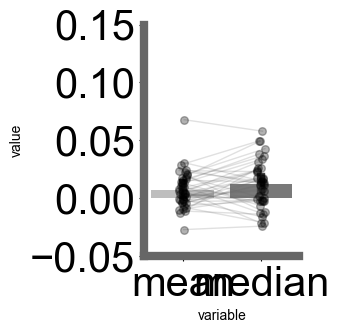

In [58]:
fs(2,3)
subj_col = 'participant'   

f = sns.barplot(x = 'variable', y = 'value',
            hue = 'variable',palette = ["#bebebeff",'#797979ff'],
            order = ['mean','median'],
            hue_order = ['mean','median'],
            errwidth= 6,
            data = image_specificity_df
            )

    
# pivot to one row per subject, one column per condition
wide_df = image_specificity_df[
    image_specificity_df.variable.isin(['mean', 'median'])
].pivot(index=subj_col, columns='variable', values='value')

# small consistent per-subject jitter so points/lines don't all overlap
rng = np.random.default_rng(0)
jitter = rng.uniform(-0.05, 0.05, size=len(wide_df))

for (subj, row), j in zip(wide_df.iterrows(), jitter):
    x0, x1 = 0 + j, 1 + j
    y0, y1 = row['mean'], row['median']
    plt.plot([x0, x1], [y0, y1], color='#666666', alpha=0.2, linewidth=1, zorder=1)
    plt.scatter([x0, x1], [y0, y1], color='black', alpha=0.3, s=30, zorder=3)

f.tick_params(labelsize=30)
for spine_name, spine in f.spines.items():
        if spine_name in ['top', 'right']:
                spine.set_visible(False)
        else:
                spine.set_linewidth(6)
                spine.set_color('#666666')

plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(0.05))
plt.tick_params(labelsize=30)
plt.ylim(-0.05,0.15)


# Supplementary Figure 1B

### precue, right

- switch 1sdelay to 2sdelay for middle

In [68]:
n_repeats = 100
diff_image_batch_size = 7

In [69]:
median_arr_all_subj = np.empty(
        (
            41,
            n_repeats
        )
)
mean_arr_all_subj = np.empty(
    (
        41,
        n_repeats
    )
)
across_same_image_median_all_subj = np.empty(41)
across_same_image_mean_all_subj = np.empty(41)
withinTrl_all_subj = np.empty(41)


In [71]:
for cnt,subjID in enumerate(trlOrdering.participant.unique()[:41].astype(int)):
    print(cnt)
    #initialize empty arrays
    withinTrl = []
    acrossTrl_sameImage_median = []
    acrossTrl_sameImage_mean = []

    # to test the effect of batch size on different images, requested by reviewer 2
    different_image_median = []
    different_image_mean = []

    thisFileID = glob.glob(f'D:/yueying/gazeObject_YueyingDong/results/variables/scanMatchTrlID/311to352_stim2delay_1sdelay/*{str(int(subjID))[:3]}*.npy')
    saccTrlIDs = np.load(thisFileID[0],allow_pickle = True)
    saccTrlIDs = [str((i.split('_')[0][1:],int(i.split('_')[1]),int(i.split('_')[2]))) for i in saccTrlIDs]
    trlInfo_thisSubj = trlOrdering[trlOrdering['TRIALID'].isin((saccTrlIDs))].reset_index(drop = True)
    similarityArr = loadScanPathRawMat_oneSubj(subjID,'stim2delay_1sdelay')

        
    #check if the trial is correct
    if sum(trlInfo_thisSubj.TRIALID != saccTrlIDs) == 0:

        #for each trial
        for n,i in enumerate(trlInfo_thisSubj.TRIALID.unique()):
        
            #get the indices of other trials with the same image
            trlThis = trlInfo_thisSubj[trlInfo_thisSubj.TRIALID == i] 
            sameImageTrls = trlInfo_thisSubj[(trlInfo_thisSubj.stimImage == trlThis.stimImage.values[0]) &
                                            (trlInfo_thisSubj.TRIALID != i)]
            sameImageIndices = sameImageTrls.index.values

            #get the indices from other trls
            diffImageTrls = trlInfo_thisSubj[(trlInfo_thisSubj.stimImage != trlThis.stimImage.values[0])]
            diffImageIndices = diffImageTrls.index.values

            q = []
            j = []
            for repeat in np.arange(n_repeats):
                this_batch_indicies = np.random.choice(diffImageIndices,
                                                       size=diff_image_batch_size, 
                                                       replace=False)
                
                q.append(
                    np.nanmedian(similarityArr[n,this_batch_indicies])
                ) 
                j.append(
                    np.nanmean(similarityArr[n,this_batch_indicies])
                    )
            
            withinTrl.append(similarityArr[n,n])
            acrossTrl_sameImage_median.append(
                                                np.nanmedian( 
                                                    similarityArr[n,sameImageIndices]
                                                    )
                                                )
            acrossTrl_sameImage_mean.append( 
                                            np.nanmean(
                                                similarityArr[n,sameImageIndices]
                                                )
                                            )

            different_image_median.append(q)                
            different_image_mean.append(j)

            

    
    median_arr_all_subj[cnt] = np.nanmean(np.array(different_image_median),axis = 0)  
    mean_arr_all_subj[cnt] = np.nanmean(np.array(different_image_mean),axis = 0)
   
    across_same_image_median_all_subj[cnt] = np.nanmean(acrossTrl_sameImage_median)
    across_same_image_mean_all_subj[cnt] = np.nanmean(acrossTrl_sameImage_mean)
    withinTrl_all_subj[cnt] = np.nanmean(withinTrl)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40


In [72]:
subj_mean = np.nanmean(median_arr_all_subj,axis = 1)
median_all_subj_df_precue = pd.DataFrame(subj_mean,columns=['diff_image_median'])
median_all_subj_df_precue['participant'] = trlOrdering.participant.unique()[41:].astype(int)
median_all_subj_df_precue['across_trial_mean'] = across_same_image_mean_all_subj
median_all_subj_df_precue['across_trial_median'] = across_same_image_median_all_subj

median_all_subj_df_precue['within_trial'] = withinTrl_all_subj
median_all_subj_df_precue['diff_image_mean'] = np.nanmean(mean_arr_all_subj,axis = 1)


median_all_subj_df_precue_long = median_all_subj_df_precue.melt(
    id_vars='participant',
    value_vars = ['diff_image_median',
                  'across_trial_median',
                  'diff_image_mean',
                  'across_trial_mean',
                  'within_trial'],
    value_name='scanpath_similarity',
    var_name= 'comparison'
)

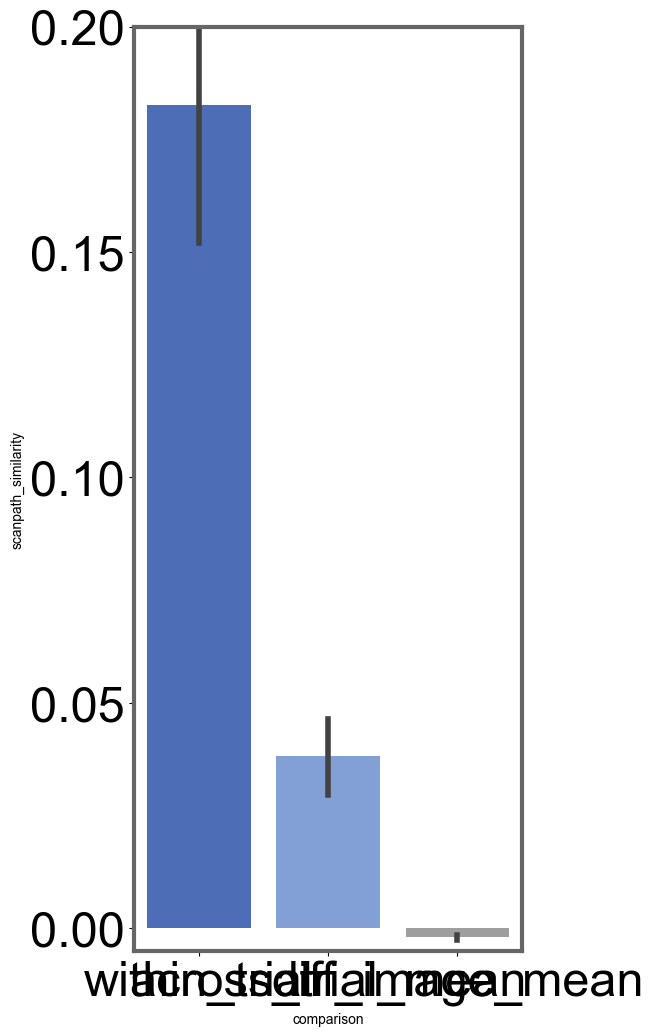

In [73]:
fs(3,5)
f = sns.barplot(x = 'comparison', y = 'scanpath_similarity',
            hue = 'comparison', 
            order = ['within_trial','across_trial_mean','diff_image_mean',],
            hue_order = ['within_trial','across_trial_mean','diff_image_mean',],
            palette= ['#3b66c8','#759ce0','#9e9e9eff',"#4e6a99","#797979ff"],
            errwidth=4,
            data = median_all_subj_df_precue_long
            )

for spine in f.spines.values():
    spine.set_linewidth(3) 
    spine.set_color('#666666')

plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(0.05))
plt.gcf().set_size_inches(5, 12)
f.axes.tick_params(labelsize=35)
plt.ylim(-0.005,0.2)
plt.subplots_adjust(wspace=0.25)

### retrocue,right

In [22]:
median_arr_all_subj = np.empty(
        (
            41,
            n_repeats
        )
)
mean_arr_all_subj = np.empty(
    (
        41,
        n_repeats
    )
)
across_same_image_median_all_subj = np.empty(41)
across_same_image_mean_all_subj = np.empty(41)
withinTrl_all_subj = np.empty(41)


In [ ]:
for cnt,subjID in enumerate(trlOrdering.participant.unique()[41:].astype(int)):
    print(cnt)
    #initialize empty arrays
    withinTrl = []
    acrossTrl_sameImage_median = []
    acrossTrl_sameImage_mean = []

    # to test the effect of batch size on different images, requested by reviewer 2
    different_image_median = []
    different_image_mean = []

    thisFileID = glob.glob(f'D:/yueying/gazeObject_YueyingDong/results/variables/scanMatchTrlID/360to400_stim2delay_1sdelay/*{str(int(subjID))[:3]}*.npy')
    saccTrlIDs = np.load(thisFileID[0],allow_pickle = True)
    saccTrlIDs = [str((i.split('_')[0][1:],int(i.split('_')[1]),int(i.split('_')[2]))) for i in saccTrlIDs]
    trlInfo_thisSubj = trlOrdering[trlOrdering['TRIALID'].isin((saccTrlIDs))].reset_index(drop = True)
    similarityArr = loadScanPathRawMat_oneSubj(subjID,'stim2delay_1sdelay')

        
    #check if the trial is correct
    if sum(trlInfo_thisSubj.TRIALID != saccTrlIDs) == 0:

        #for each trial
        for n,i in enumerate(trlInfo_thisSubj.TRIALID.unique()):
        
            #get the indices of other trials with the same image
            trlThis = trlInfo_thisSubj[trlInfo_thisSubj.TRIALID == i] 
            sameImageTrls = trlInfo_thisSubj[(trlInfo_thisSubj.stimImage == trlThis.stimImage.values[0]) &
                                            (trlInfo_thisSubj.TRIALID != i)]
            sameImageIndices = sameImageTrls.index.values

            #get the indices from other trls
            diffImageTrls = trlInfo_thisSubj[(trlInfo_thisSubj.stimImage != trlThis.stimImage.values[0])]
            diffImageIndices = diffImageTrls.index.values

            q = []
            j = []
            for repeat in np.arange(n_repeats):
                this_batch_indicies = np.random.choice(diffImageIndices,
                                                       size=diff_image_batch_size, 
                                                       replace=False)
                
                q.append(
                    np.nanmedian(similarityArr[n,this_batch_indicies])
                ) 
                j.append(
                    np.nanmean(similarityArr[n,this_batch_indicies])
                    )
            
            withinTrl.append(similarityArr[n,n])
            acrossTrl_sameImage_median.append(
                                                np.nanmedian( 
                                                    similarityArr[n,sameImageIndices]
                                                    )
                                                )
            acrossTrl_sameImage_mean.append( 
                                            np.nanmean(
                                                similarityArr[n,sameImageIndices]
                                                )
                                            )

            different_image_median.append(q)                
            different_image_mean.append(j)

            

    
    median_arr_all_subj[cnt] = np.nanmean(np.array(different_image_median),axis = 0)  
    mean_arr_all_subj[cnt] = np.nanmean(np.array(different_image_mean),axis = 0)
   
    across_same_image_median_all_subj[cnt] = np.nanmean(acrossTrl_sameImage_median)
    across_same_image_mean_all_subj[cnt] = np.nanmean(acrossTrl_sameImage_mean)
    withinTrl_all_subj[cnt] = np.nanmean(withinTrl)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40


In [24]:
subj_mean = np.nanmean(median_arr_all_subj,axis = 1)
median_all_subj_df_retrocue = pd.DataFrame(subj_mean,columns=['diff_image_median'])
median_all_subj_df_retrocue['participant'] = trlOrdering.participant.unique()[41:].astype(int)
median_all_subj_df_retrocue['across_trial_mean'] = across_same_image_mean_all_subj
median_all_subj_df_retrocue['across_trial_median'] = across_same_image_median_all_subj

median_all_subj_df_retrocue['within_trial'] = withinTrl_all_subj
median_all_subj_df_retrocue['diff_image_mean'] = np.nanmean(mean_arr_all_subj,axis = 1)


median_all_subj_df_retrocue_long = median_all_subj_df_retrocue.melt(
    id_vars='participant',
    value_vars = ['diff_image_median',
                  'across_trial_median',
                  'diff_image_mean',
                  'across_trial_mean',
                  'within_trial'],
    value_name='scanpath_similarity',
    var_name= 'comparison'
)

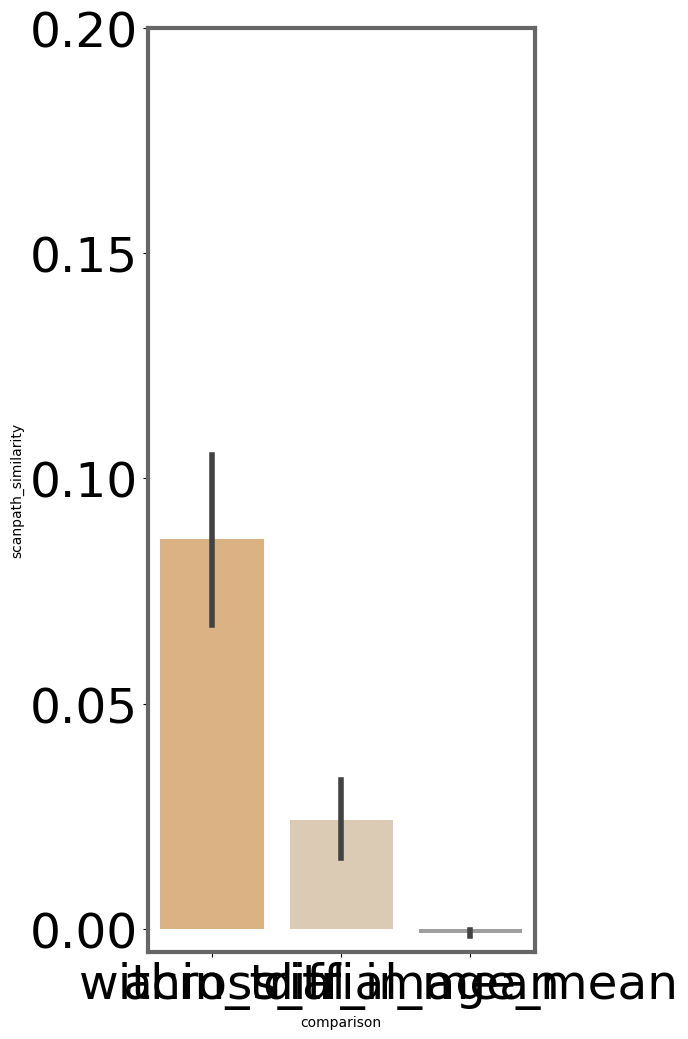

In [25]:
fs(3,5)
f = sns.barplot(x = 'comparison', y = 'scanpath_similarity',
            hue = 'comparison', 
            order = ['within_trial','across_trial_mean','diff_image_mean'],
            hue_order = ['within_trial','across_trial_mean','diff_image_mean',
                         ],
            palette= ['#eab375','#e2ccae','#9e9e9eff',],
            errwidth = 4,
            data = median_all_subj_df_retrocue_long
            )
for spine in f.spines.values():
    spine.set_linewidth(3) 
    spine.set_color('#666666')

plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(0.05))
plt.gcf().set_size_inches(5, 12)
f.axes.tick_params(labelsize=35)
plt.ylim(-0.005,0.2)
plt.subplots_adjust(wspace=0.25)

(-0.30000000000000004, 6.3, -0.005000000000000001, 0.10500000000000001)

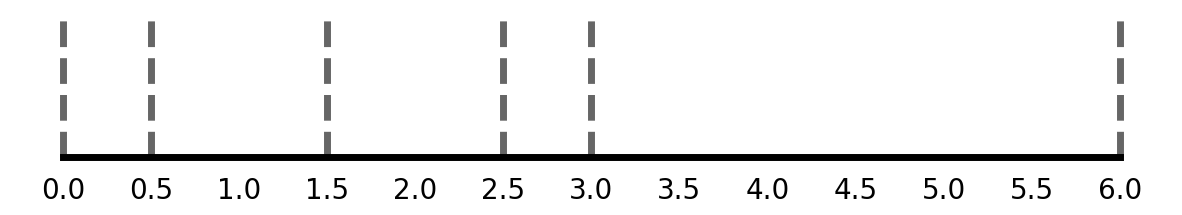

In [162]:
fs(15,2)


plt.vlines(
    [0,0.5,1.5,2.5,3,6],
    0,0.1,
    linestyles='dashed',
    colors='#666666',
    linewidth = 5
)

plt.plot(
        np.linspace(0,6,60),
        np.zeros(60),
        linewidth = 5,
        c = 'black'
        )

for t in np.arange(0,6.001,0.5):
    plt.text(t, -0.03, str(t), ha='center', fontsize=20)


plt.axis('off')


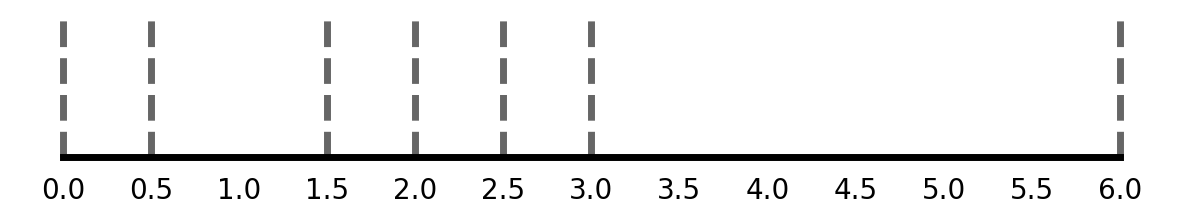

In [163]:
fs(15,2)


plt.vlines(
    [0,0.5,1.5,2,2.5,3,6],
    0,0.1,
    linestyles='dashed',
    colors='#666666',
    linewidth = 5
)

plt.plot(
        np.linspace(0,6,60),
        np.zeros(60),
        linewidth = 5,
        c = 'black'
        )

plt.axis('off')

for t in np.arange(0,6.001,0.5):
    plt.text(t, -0.03, str(t), ha='center', fontsize=20)
